In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [68]:
df=pd.read_csv("../data/DataWithDescriptors.csv")
cation_pka=pd.read_excel("../data/pkacation.xlsx")
anion_pka=pd.read_excel("../data/pkaanion.xlsx")
print(df.shape)
print(cation_pka.shape)
print(anion_pka.shape)

(5349, 444)
(77, 2)
(80, 2)


In [69]:
df["IL NAME"] = (
    
    df["CATION NAME"].astype(str) +
    " " +
    df["ANION NAME"].astype(str) )

In [70]:
ffv=pd.read_csv("../outputs/tables/unique_ionic_liquids_with_ffv.csv")

In [71]:
df = df.merge(ffv[["IL NAME", "FFV"]],on="IL NAME",how="left")

In [73]:
cation_pka=cation_pka.rename(columns={ "CATION": 'CATION NAME' })

In [74]:
anion_pka=anion_pka.rename(columns={"Anion":"ANION NAME"})

In [75]:
df = pd.merge(df,cation_pka,on="CATION NAME",how="left")

In [76]:
df = pd.merge(df,anion_pka,on="ANION NAME",how="left")

In [77]:
df["CATION_pKa"].isnull().sum()

np.int64(0)

In [78]:
df["Anion_pKa"].isnull().sum()

np.int64(0)

In [79]:
df["Delta_pKa"] = df["CATION_pKa"] - df["Anion_pKa"]

C:\Users\BIT\AppData\Local\Temp\ipykernel_18488\3233356666.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Delta_pKa"] = df["CATION_pKa"] - df["Anion_pKa"]


In [80]:
df["Delta_pKa"].describe()

count    5349.000000
mean       27.186790
std         7.859206
min        -4.200000
25%        21.600000
50%        26.300000
75%        34.000000
max        39.000000
Name: Delta_pKa, dtype: float64

In [104]:
df[df["Delta_pKa"] < 2][
    [
        "CATION NAME",
        "ANION NAME",
        "CATION_pKa",
        "Anion_pKa",
        "Delta_pKa"
    ]
]

,CATION NAME,ANION NAME,CATION_pKa,Anion_pKa,Delta_pKa
16,triethylenetetrammonium,piperazine,10.3,9.80,0.50
17,triethylenetetrammonium,imidazolate,10.3,14.50,-4.20
19,triethylenetetrammonium,"1,2,4-triazolate",10.3,10.20,0.10
41,"N, N-dimethyl-1,3-propane diamine",p-fluorophenolate,10.8,9.95,0.85


In [82]:
known_ffv = df[df["FFV"].notna()].copy()

In [83]:
known_ffv.columns

Index(['Unnamed: 0', 'IL NAME', 'CATION NAME', 'ANION NAME', 'Cation_SMILES',
       'Anion_SMILES', 'Temperature (0 C)', 'Pressure (bar)',
       'CO2 capacity (mol CO2/mol IL)', 'Cation_Family',
       ...
       'An_fr_tetrazole', 'An_fr_thiazole', 'An_fr_thiocyan',
       'An_fr_thiophene', 'An_fr_unbrch_alkane', 'An_fr_urea', 'FFV',
       'CATION_pKa', 'Anion_pKa', 'Delta_pKa'],
      dtype='str', length=448)

In [84]:
x=known_ffv[["Temperature (0 C)","Pressure (bar)","Delta_pKa","FFV"]]

In [85]:
y=known_ffv["CO2 capacity (mol CO2/mol IL)"]

In [86]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape,y_train.shape, y_test.shape)
import xgboost as xgb
model = xgb.XGBRegressor(objective='reg:squarederror',n_estimators=100, random_state=42)
model.fit(X_train,y_train)
y_train_pred=model.predict(X_train)
y_pred=model.predict(X_test)
from sklearn.metrics import(r2_score,mean_absolute_error,mean_squared_error)
r2=r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
train_r2 = r2_score(y_train,y_train_pred)
print("Train R2:", round(train_r2,4))
print("TEST METRICS ARE")
print("R2 :", round(r2,4))
print("MAE :", round(mae,4))
print("RMSE :", round(rmse,4))

(3392, 4) (849, 4) (3392,) (849,)
Train R2: 0.9986
TEST METRICS ARE
R2 : 0.9737
MAE : 0.0317
RMSE : 0.0709


In [87]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model,X_train,y_train,cv=10,scoring="r2",n_jobs=-1)
print("Fold Scores:")
print(cv_scores)
print()
print("Mean CV R2:",round(cv_scores.mean(),4))
print("Std CV R2:",round(cv_scores.std(),4))

Fold Scores:
[0.94733086 0.97416035 0.9725221  0.96780596 0.96601968 0.97903458
 0.97713885 0.97901786 0.88872884 0.97025688]

Mean CV R2: 0.9622
Std CV R2: 0.026


In [89]:
corr_df = df[
    [
        "Temperature (0 C)",
        "Pressure (bar)",
        "CATION_pKa",
        "Anion_pKa",
        "Delta_pKa",
        "FFV",
        "CO2 capacity (mol CO2/mol IL)"
    ]
].corr()

corr_df

,Temperature (0 C),Pressure (bar),CATION_pKa,Anion_pKa,Delta_pKa,FFV,CO2 capacity (mol CO2/mol IL)
Temperature (0 C),1.000000,0.361796,0.022947,-0.037749,0.044114,0.043401,-0.032505
Pressure (bar),0.361796,1.000000,0.058660,-0.019446,0.053671,-0.085553,0.495167
CATION_pKa,0.022947,0.058660,1.000000,0.024425,0.641946,-0.021652,-0.097684
Anion_pKa,-0.037749,-0.019446,0.024425,1.000000,-0.750841,-0.115947,-0.000289
Delta_pKa,0.044114,0.053671,0.641946,-0.750841,1.000000,0.072193,-0.064316
FFV,0.043401,-0.085553,-0.021652,-0.115947,0.072193,1.000000,-0.074025
CO2 capacity (mol CO2/mol IL),-0.032505,0.495167,-0.097684,-0.000289,-0.064316,-0.074025,1.000000


In [91]:
import shap

In [92]:
explainer = shap.TreeExplainer(model)

In [93]:
print(shap_values.shape)

(849, 4)


In [94]:
shap_values = explainer.shap_values(X_test)

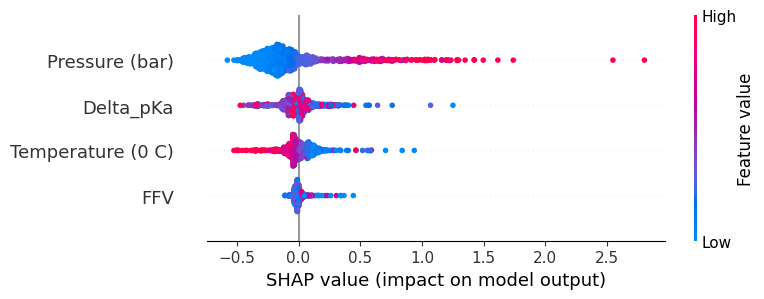

In [95]:
shap.summary_plot(
    shap_values,
    X_test
)

In [97]:
features=pd.read_excel('../outputs/tables/RF_Top20_Features.xlsx')

In [98]:
rf_features = features.iloc[:,0].tolist()

In [99]:
extra_features = [
    "CATION_pKa",
    "Anion_pKa",
    "Delta_pKa",
    "FFV"
]

all_features = list(set(rf_features + extra_features))

In [100]:
x =known_ffv[all_features]
y=known_ffv["CO2 capacity (mol CO2/mol IL)"]

In [101]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape,y_train.shape, y_test.shape)
import xgboost as xgb
model = xgb.XGBRegressor(objective='reg:squarederror',n_estimators=100, random_state=42)
model.fit(X_train,y_train)
y_train_pred=model.predict(X_train)
y_pred=model.predict(X_test)
from sklearn.metrics import(r2_score,mean_absolute_error,mean_squared_error)
r2=r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
train_r2 = r2_score(y_train,y_train_pred)
print("Train R2:", round(train_r2,4))
print("TEST METRICS ARE")
print("R2 :", round(r2,4))
print("MAE :", round(mae,4))
print("RMSE :", round(rmse,4))

(3392, 24) (849, 24) (3392,) (849,)
Train R2: 0.9992
TEST METRICS ARE
R2 : 0.9738
MAE : 0.0253
RMSE : 0.0708


In [102]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape,y_train.shape, y_test.shape)
import xgboost as xgb
model = xgb.XGBRegressor(objective='reg:squarederror',n_estimators=100, random_state=42)
model.fit(X_train,y_train)
y_train_pred=model.predict(X_train)
y_pred=model.predict(X_test)
from sklearn.metrics import(r2_score,mean_absolute_error,mean_squared_error)
r2=r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
train_r2 = r2_score(y_train,y_train_pred)
print("Train R2:", round(train_r2,4))
print("TEST METRICS ARE")
print("R2 :", round(r2,4))
print("MAE :", round(mae,4))
print("RMSE :", round(rmse,4))

(3392, 24) (849, 24) (3392,) (849,)
Train R2: 0.9992
TEST METRICS ARE
R2 : 0.9738
MAE : 0.0253
RMSE : 0.0708


In [103]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model,X_train,y_train,cv=10,scoring="r2",n_jobs=-1)
print("Fold Scores:")
print(cv_scores)
print()
print("Mean CV R2:",round(cv_scores.mean(),4))
print("Std CV R2:",round(cv_scores.std(),4))

Fold Scores:
[0.97630969 0.98739523 0.9846668  0.9846477  0.97548672 0.99063642
 0.98367255 0.98766178 0.96375825 0.95609051]

Mean CV R2: 0.979
Std CV R2: 0.0107
